🎯 Target Project Root: /Users/etiennerv/Jts/EUA Forecasting/EUA-forecasting
✅ Custom evaluation module imported successfully!
📊 Dataset loaded successfully. Commencing visual plot build...
Calculating final evaluation statistics...

=== XGBoost Baseline ===
  RMSE              : 0.03 EUR/tCO2
  MAE               : 0.02 EUR/tCO2
  MAPE              : 0.09%
  Directional Acc.  : 95.7%
🎉 SUCCESS! Saved beautiful evaluation plot to: /Users/etiennerv/Jts/EUA Forecasting/EUA-forecasting/figures/oos_forecast.png


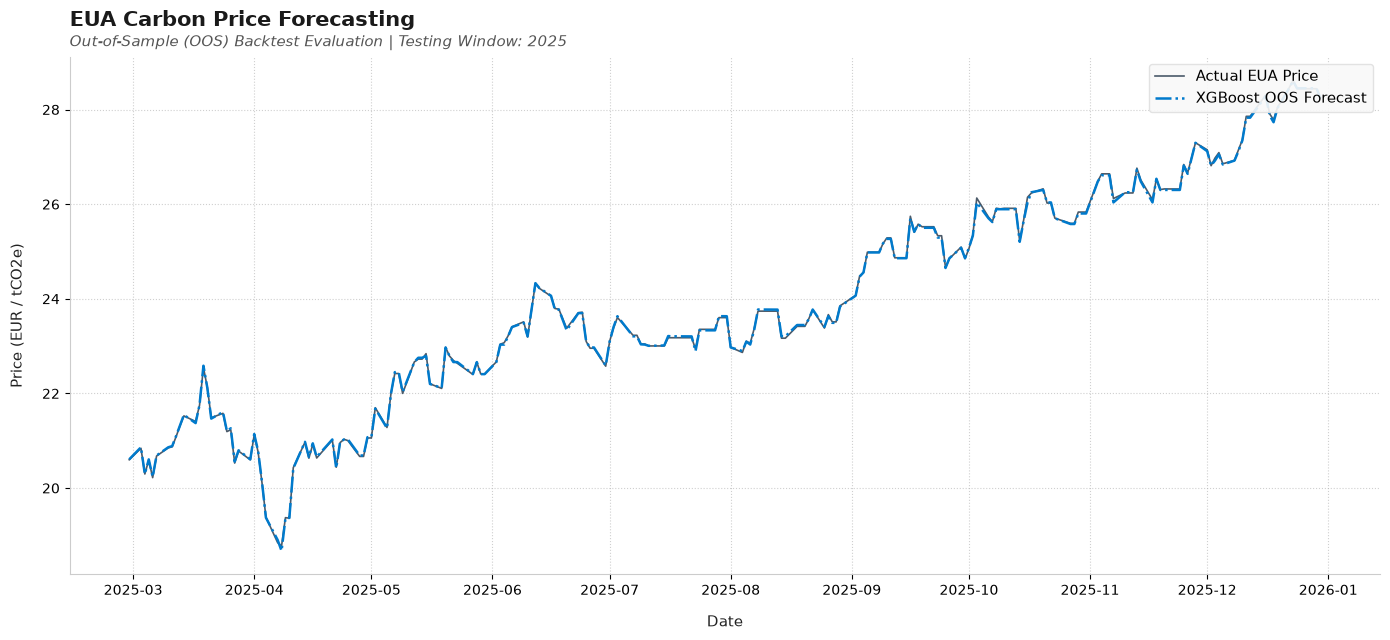

In [3]:
# =========================================================
# STEP 1: BULLETPROOF MODULE PATH INJECTION
# =========================================================
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get current notebook folder path
current_dir = os.getcwd()

# Search upward for where the actual 'src' directory lives
if os.path.exists(os.path.join(current_dir, "src")):
    PROJECT_ROOT = current_dir
elif os.path.exists(os.path.join(current_dir, "..", "src")):
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, ".."))
else:
    # Hardcoded fallback target based on your system configuration
    PROJECT_ROOT = "/Users/etiennerv/Jts/EUA Forecasting/EUA-forecasting"

# Force inject the root path to the front of Python's lookup registry
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"🎯 Target Project Root: {PROJECT_ROOT}")

# =========================================================
# STEP 2: IMPORT CUSTOM MODULE AND LOAD DATA
# =========================================================
from src.evaluate import evaluate_forecast

print("✅ Custom evaluation module imported successfully!")

# Read the generated backtest predictions file using absolute matching
xgb_preds_path = os.path.join(PROCESSED_DIR, "xgb_preds.csv")
xgb_results = pd.read_csv(xgb_preds_path, index_col=0, parse_dates=True)
print("📊 Dataset loaded successfully. Commencing visual plot build...")

# =========================================================
# STEP 3: RUN EVALUATION & SAVE FINAL GRAPH (POLISHED)
# =========================================================
print("Calculating final evaluation statistics...")
metrics = evaluate_forecast(xgb_results["actual"], xgb_results["xgb_pred"], "XGBoost Baseline")

# Create a clean, widescreen canvas
fig, ax = plt.subplots(figsize=(14, 6.5))

# Plot Actuals with a professional slate color and clean line weight
ax.plot(
    xgb_results.index, 
    xgb_results["actual"], 
    label="Actual EUA Price", 
    color="#2c3e50", 
    alpha=0.85, 
    linewidth=1.2
)

# Plot Forecast with a modern high-contrast blue and a distinct dash pattern
ax.plot(
    xgb_results.index, 
    xgb_results["xgb_pred"], 
    label="XGBoost OOS Forecast", 
    color="#007acc", 
    linestyle="-.", 
    linewidth=1.8
)

# Sophisticated Title Hierarchy (Left-aligned, clean layout)
ax.set_title("EUA Carbon Price Forecasting", fontsize=15, fontweight="bold", pad=22, loc="left", color="#1a1a1a")
ax.text(
    0.0, 1.02, 
    "Out-of-Sample (OOS) Backtest Evaluation | Testing Window: 2025", 
    transform=ax.transAxes, 
    fontsize=11, 
    color="#555555", 
    style="italic"
)

# Axis labels styling
ax.set_xlabel("Date", fontsize=11, fontweight="medium", labelpad=12, color="#222222")
ax.set_ylabel("Price (EUR / tCO2e)", fontsize=11, fontweight="medium", labelpad=12, color="#222222")

# Clean, professional background gridlines
ax.grid(True, linestyle=":", alpha=0.6, color="#b0b0b0")

# Remove top and right box borders (spines) for a modern flat UI look
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Lighten left and bottom borders so they aren't aggressively black
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

# Beautiful, clean legend box with a light background frame
ax.legend(
    loc="upper right", 
    frameon=True, 
    facecolor="#f9f9f9", 
    edgecolor="#e0e0e0", 
    framealpha=0.9, 
    fontsize=10.5
)

# Prevent formatting layout cutoffs
plt.tight_layout()

# Save over the old file with zero border padding clipping
final_plot_path = os.path.join(FIGURES_DIR, "oos_forecast.png")
plt.savefig(final_plot_path, dpi=150, bbox_inches="tight")

print(f"🎉 SUCCESS! Saved beautiful evaluation plot to: {final_plot_path}")
plt.show()